Predict the DECam z mag and GAIA G mag using 2MASS and Tycho2 magnitudes

In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
nmad = lambda x: 1.4826 * np.median(np.abs(x-np.median(x)))

In [4]:
gaia = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/gaia_edr3_g_14_pm_dr9.fits'))

mask = gaia['PHOT_G_MEAN_MAG']<12
print(np.sum(mask)/len(mask))
gaia = gaia[mask]

# Coefficients for EDR3
coeffs = dict(
    g = [-0.1125681175, 0.3506376997, 0.9082025788, -1.0078309266,
        -1.4212131445, 4.5685722177, -4.5719415419, 2.3816887292,
        -0.7162270722, 0.1247021438, -0.0114938710, 0.0003949585,
        0.0000051647],
    r = [0.1431278873, -0.2999797766, -0.0553379742, 0.1544273115,
        0.3068634689, -0.9499143903, 0.9769739362, -0.4926704528,
        0.1272539574, -0.0133178183, -0.0008153813, 0.0003094116,
        -0.0000198891],
    z = [0.5173814296, -1.0450176704, 0.1529797809, 0.1856005222,
        -0.2366580132, 0.1018331214, -0.0189673240, 0.0012988354])

bprp_min, bprp_max = -0.5, 4.7

for i, band in enumerate(['g', 'r', 'z']):
    mag = np.copy(gaia['PHOT_G_MEAN_MAG'])
    for order, c in enumerate(coeffs[band]):
        x = gaia['PHOT_BP_MEAN_MAG']-gaia['PHOT_RP_MEAN_MAG']
        x = np.clip(x, bprp_min, bprp_max)
        mag += c * (x)**order
    gaia['decam_mag_'+band] = mag
    
mask = (gaia['PHOT_BP_MEAN_MAG']==0) | (gaia['PHOT_RP_MEAN_MAG']==0)
# for band in ['g', 'r', 'z']:
#     gaia['decam_mag_'+band][mask] = np.nan
print(np.sum(mask))
gaia = gaia[~mask]

0.22808040302272004
1343


In [5]:
tycho2 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/tycho2-reference-dr9.fits'))

mask = tycho2['MAG_VT']<10
tycho2 = tycho2[mask]
print(len(tycho2))

mask = tycho2['MAG_VT']!=0
print(np.sum(~mask))
tycho2 = tycho2[mask]
print(len(tycho2))

128501
1473
127028


In [6]:
twomass = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/2mass_psc/2mass_psc_j_12-dr9.fits'))

mask = twomass['Jmag']<11
twomass = twomass[mask]
print(len(twomass))

1132120


In [7]:
gaia['RA2000'] = gaia['RA'] - 16 * gaia['PMRA'] * 1e-3/3600 / np.cos(np.radians(gaia['DEC']))
gaia['DEC2000'] = gaia['DEC'] - 16 * gaia['PMDEC'] * 1e-3/3600

mask = (tycho2['EPOCH_RA']!=0) & (tycho2['EPOCH_DEC']!=0)
tycho_ra_j2000 = tycho2['RA'].copy()
tycho_dec_j2000 = tycho2['DEC'].copy()
tycho_ra_j2000[mask] = (tycho2['RA'] - (tycho2['EPOCH_RA']-2000.) * tycho2['PM_RA'] * 1/3600 / np.cos(np.radians(tycho2['DEC'])))[mask]
tycho_dec_j2000[mask] = (tycho2['DEC'] - (tycho2['EPOCH_DEC']-2000.) * tycho2['PM_DEC'] * 1/3600)[mask]

Doubly matched objects = 0
Final matched objects = 125812


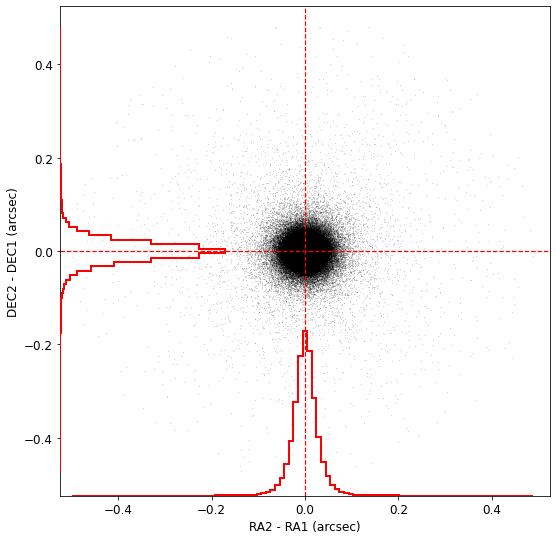

0.13709894483111087
0.9904273073653053


In [8]:
sys.path.append(os.path.expanduser('~/git/Python/user_modules/'))
from match_coord import match_coord

idx1, idx2, d2d, d_ra, d_dec = match_coord(gaia['RA2000'], gaia['DEC2000'], tycho_ra_j2000, tycho_dec_j2000, search_radius=0.5, plot_q=True)
print(len(idx1)/len(gaia))
print(len(idx1)/len(tycho2))

In [9]:
gaia = gaia[idx1]
tycho2 = tycho2[idx2]

Doubly matched objects = 4
Final matched objects = 124076


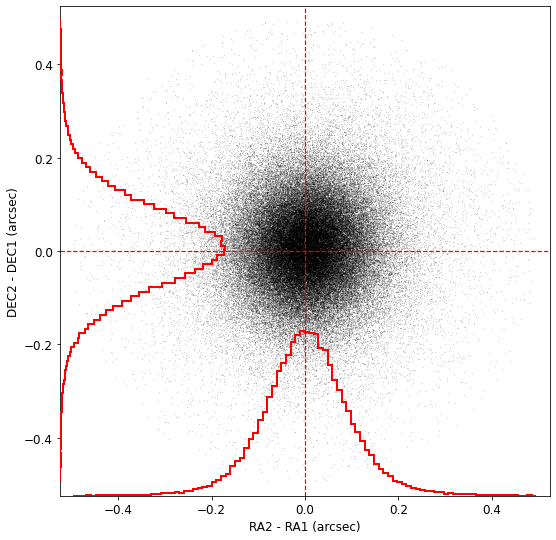

0.9862016341843385
0.10959615588453521


In [10]:
sys.path.append(os.path.expanduser('~/git/Python/user_modules/'))
from match_coord import match_coord

idx1, idx2, d2d, d_ra, d_dec = match_coord(gaia['RA2000'], gaia['DEC2000'], twomass['RA'], twomass['DEC'], search_radius=0.5, plot_q=True)
print(len(idx1)/len(gaia))
print(len(idx1)/len(twomass))

In [11]:
gaia = gaia[idx1]
tycho2 = tycho2[idx1]
twomass = twomass[idx2]

In [12]:
gaia[:1]

SOURCE_ID,RA,DEC,PHOT_G_MEAN_MAG,PHOT_G_MEAN_FLUX_OVER_ERROR,PHOT_BP_MEAN_MAG,PHOT_RP_MEAN_MAG,ASTROMETRIC_EXCESS_NOISE,PARALLAX,PARALLAX_ERROR,PMRA,PMRA_ERROR,PMDEC,PMDEC_ERROR,decam_mag_g,decam_mag_r,decam_mag_z,RA2000,DEC2000
int64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64
215820835313697408,89.98790268039771,53.16273782208863,9.56753,3892.6504,9.699432,9.320604,0.12422735,3.9001667,0.016970987,5.839834,0.017648973,-25.442123,0.015119232,9.658582,9.598768,9.71694,89.98785938948015,53.1628508982043


----------
# zguss

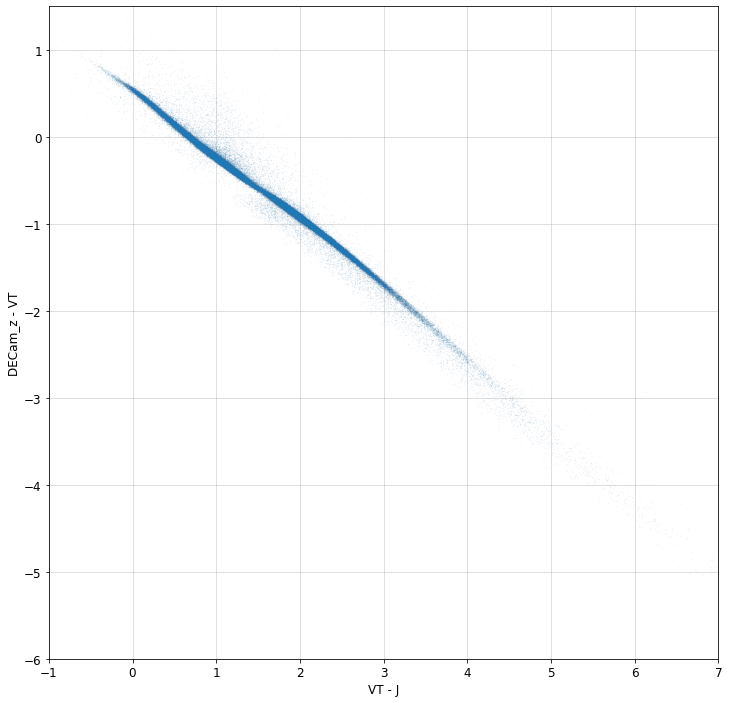

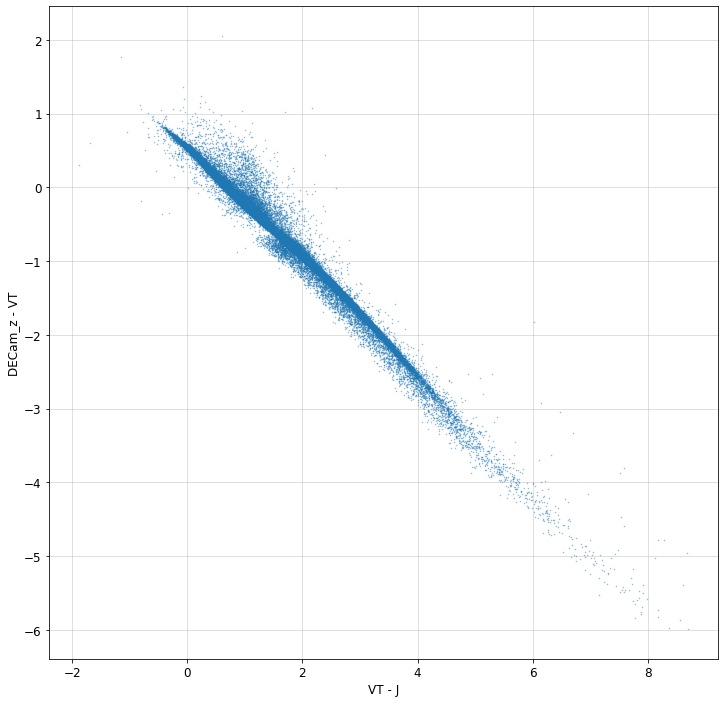

In [13]:
plt.figure(figsize=(12, 12))
plt.plot((tycho2['MAG_VT']-twomass['Jmag']), gaia['decam_mag_z'] - tycho2['MAG_VT'], '.', ms=0.1, alpha=0.5)
plt.xlabel('VT - J')
plt.ylabel('DECam_z - VT')
plt.axis([-1, 7, -6, 1.5])
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(12, 12))
plt.plot((tycho2['MAG_VT']-twomass['Jmag']), gaia['decam_mag_z'] - tycho2['MAG_VT'], '.', ms=1, alpha=0.5)
plt.xlabel('VT - J')
plt.ylabel('DECam_z - VT')
# plt.axis([-1, 7, -6, 1.5])
plt.grid(alpha=0.5)
plt.show()

In [14]:
x, y = tycho2['MAG_VT']-twomass['Jmag'], gaia['decam_mag_z'] - tycho2['MAG_VT']

In [15]:
coeffs_z = np.polyfit(x, y, 2)
print(coeffs_z)

[-0.01744964 -0.68341173  0.49427122]


In [16]:
# Use the parameters used in the v1 mask
coeffs_z = np.array([-0.01835938, -0.68084937,  0.49222576])
print(coeffs_z)
p = np.poly1d(coeffs_z)

[-0.01835938 -0.68084937  0.49222576]


In [17]:
xmin, xmax = -1, 8

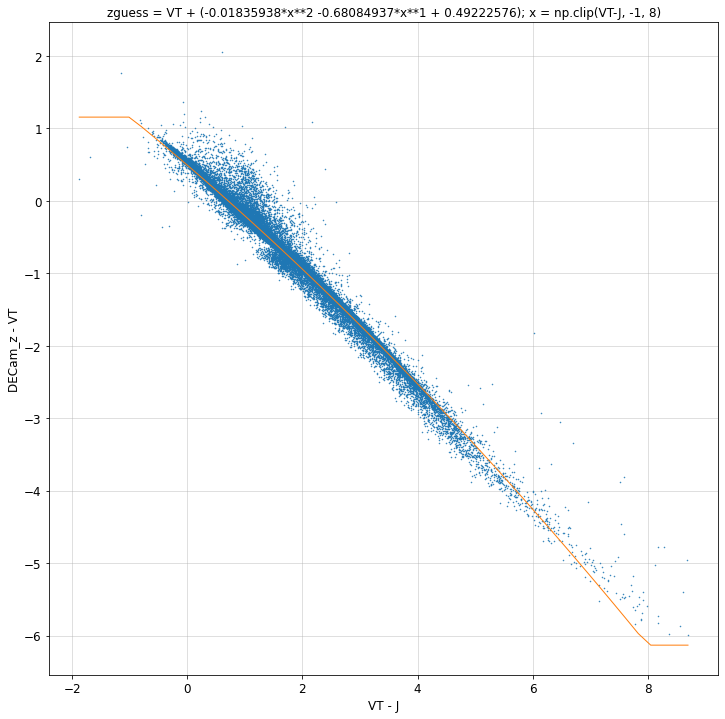

0.07815031
0.0417155161857605


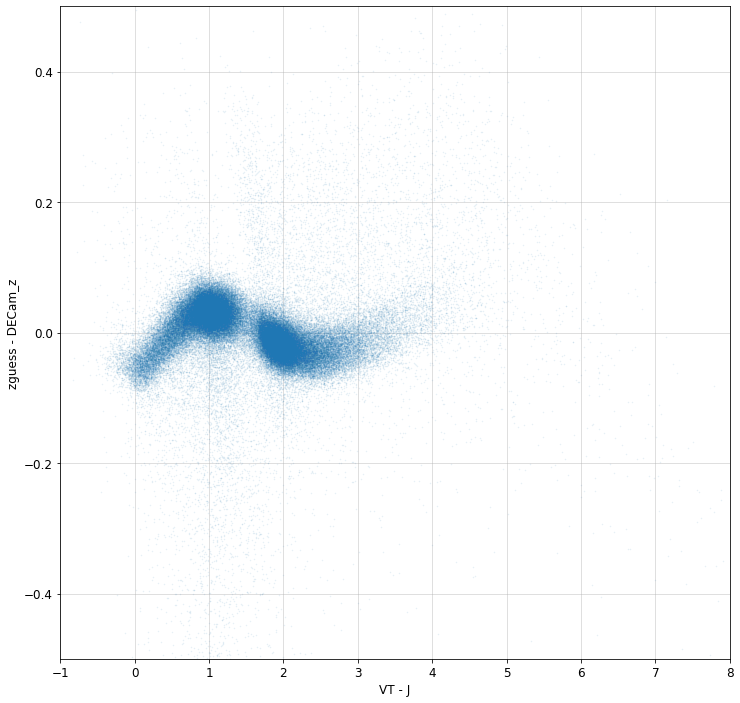

In [18]:
x_plot = np.linspace(x.min(), x.max())
y_plot = p(np.clip(x_plot, xmin, xmax))

plt.figure(figsize=(12, 12))
plt.plot(tycho2['MAG_VT']-twomass['Jmag'], gaia['decam_mag_z'] - tycho2['MAG_VT'], '.', ms=1, alpha=1)
plt.plot(x_plot, y_plot, lw=1)
plt.title('zguess = VT + (-0.01835938*x**2 -0.68084937*x**1 + 0.49222576); x = np.clip(VT-J, -1, 8)')
# plt.axis([-1, 8, -6, 1.5])
plt.xlabel('VT - J')
plt.ylabel('DECam_z - VT')
plt.grid(alpha=0.5)
plt.show()

zguess = p(np.clip(tycho2['MAG_VT']-twomass['Jmag'], xmin, xmax)) + tycho2['MAG_VT']
print(np.std(zguess-(gaia['decam_mag_z'])))
print(nmad(zguess-(gaia['decam_mag_z'])))

plt.figure(figsize=(12, 12))
plt.plot(tycho2['MAG_VT']-twomass['Jmag'], zguess-gaia['decam_mag_z'], '.', ms=1, alpha=0.1)
plt.xlabel('VT - J')
plt.ylabel('zguess - DECam_z')
plt.axis([-1, 8, -0.5, 0.5])
plt.grid(alpha=0.5)
plt.show()

------
# ggguess

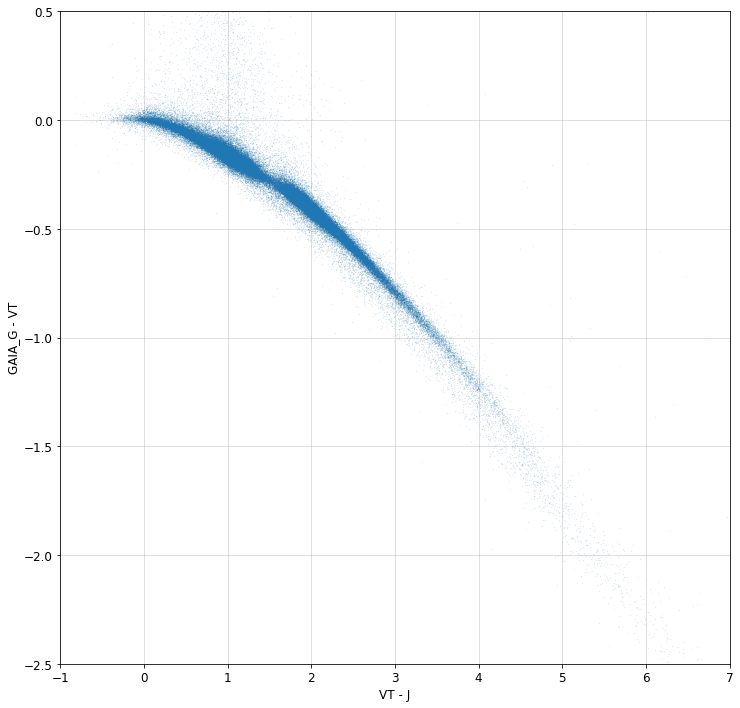

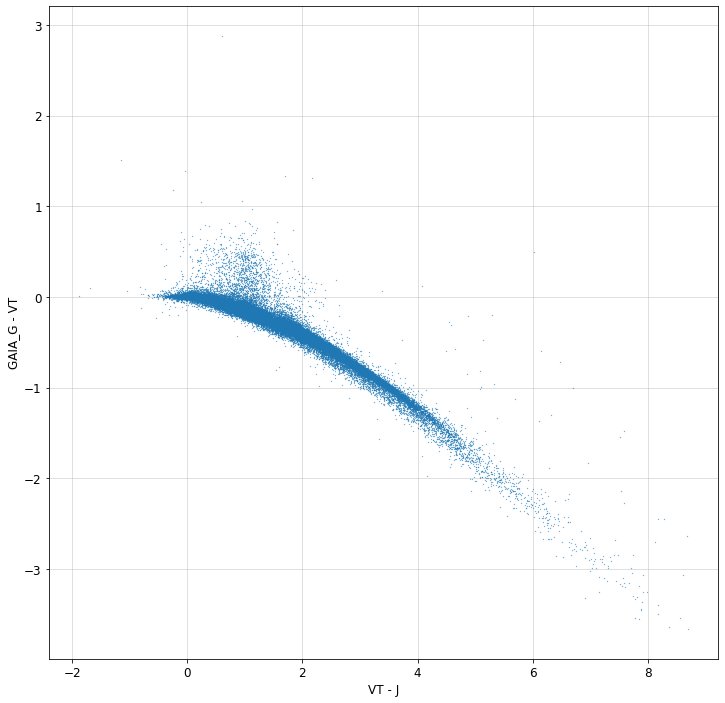

In [19]:
plt.figure(figsize=(12, 12))
plt.plot((tycho2['MAG_VT']-twomass['Jmag']), gaia['PHOT_G_MEAN_MAG'] - tycho2['MAG_VT'], '.', ms=0.2, alpha=0.5)
plt.axis([-1, 7, -2.5, 0.5])
plt.xlabel('VT - J')
plt.ylabel('GAIA_G - VT')
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(12, 12))
plt.plot(tycho2['MAG_VT']-twomass['Jmag'], gaia['PHOT_G_MEAN_MAG'] - tycho2['MAG_VT'], '.', ms=0.5)
# plt.axis([-1, 7, -2.5, 0.5])
plt.xlabel('VT - J')
plt.ylabel('GAIA_G - VT')
plt.grid(alpha=0.5)
plt.show()

In [20]:
x, y = tycho2['MAG_VT']-twomass['Jmag'], gaia['PHOT_G_MEAN_MAG'] - tycho2['MAG_VT']

In [21]:
coeffs_gg = np.polyfit(x, y, 3)
print(coeffs_gg)

[ 0.00463946 -0.07842177 -0.07140042  0.00319671]


In [22]:
# Use the parameters used in the v1 mask
coeffs_gg = np.array([ 0.00445346, -0.07819228, -0.07145574,  0.00278177])
print(coeffs_gg)
p = np.poly1d(coeffs_gg)

[ 0.00445346 -0.07819228 -0.07145574  0.00278177]


In [23]:
xmin, xmax = -1, 8

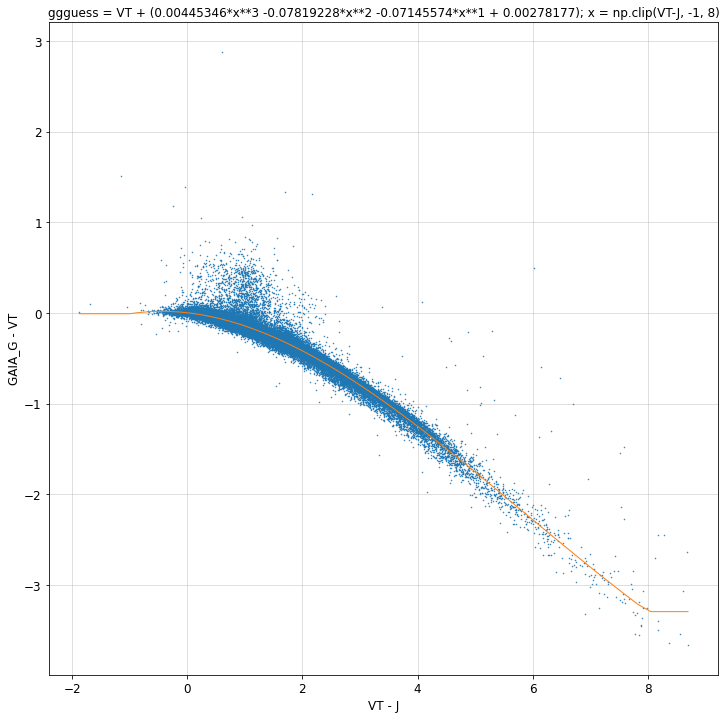

0.061870072
0.025999115753173825


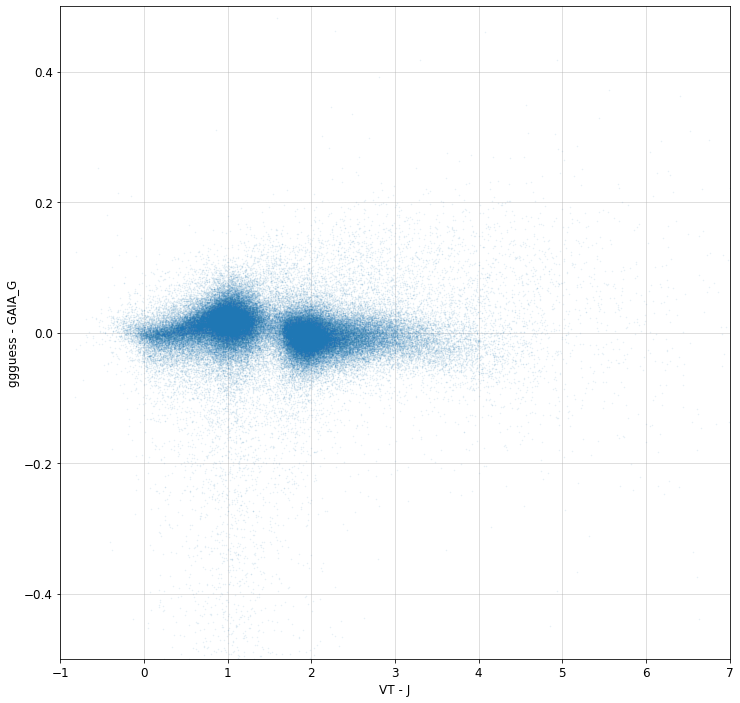

In [24]:
x_plot = np.linspace(x.min(), x.max())
y_plot = p(np.clip(x_plot, xmin, xmax))

plt.figure(figsize=(12, 12))
plt.plot(tycho2['MAG_VT']-twomass['Jmag'], gaia['PHOT_G_MEAN_MAG'] - tycho2['MAG_VT'], '.', ms=1, alpha=1)
plt.plot(x_plot, y_plot, lw=1)
plt.title('ggguess = VT + (0.00445346*x**3 -0.07819228*x**2 -0.07145574*x**1 + 0.00278177); x = np.clip(VT-J, -1, 8)')
# plt.axis([-1, 7, -2.5, 0.5])
plt.xlabel('VT - J')
plt.ylabel('GAIA_G - VT')
plt.grid(alpha=0.5)
plt.show()

ggguess = p(np.clip(tycho2['MAG_VT']-twomass['Jmag'], xmin, xmax)) + tycho2['MAG_VT']
print(np.std(ggguess-(gaia['PHOT_G_MEAN_MAG'])))
print(nmad(ggguess-(gaia['PHOT_G_MEAN_MAG'])))

plt.figure(figsize=(12, 12))
plt.plot(tycho2['MAG_VT']-twomass['Jmag'], ggguess-gaia['PHOT_G_MEAN_MAG'], '.', ms=1, alpha=0.1)
plt.axis([-1, 7, -0.5, 0.5])
plt.xlabel('VT - J')
plt.ylabel('ggguess - GAIA_G')
plt.grid(alpha=0.5)
plt.show()

-------

In [25]:
coeffs_z

array([-0.01835938, -0.68084937,  0.49222576])

In [26]:
coeffs_gg

array([ 0.00445346, -0.07819228, -0.07145574,  0.00278177])